In [266]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

#### <font color='red'>本文件使用了大纲，右键可以查看</font>

### 数据导入

In [267]:
df1=pd.read_excel(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-12\缺陷检测.xlsx")

In [268]:
df=df1

In [269]:
df.head(3)

,时间X1,缺陷累计产生数量X2,特征X3,特征X4,特征X5,特征X6,特征X7,特征X8,特征X9,缺陷检测质量风险 Y
0,2050-12-31 06:43:39,0,40,43,0,0,0,0,0,无质量隐患
1,2050-12-31 06:44:09,0,120,146,0,0,0,0,0,NaN
2,2050-12-31 06:44:39,0,120,146,0,0,0,0,0,NaN


In [270]:
df['缺陷检测质量风险 Y'].value_counts()

缺陷检测质量风险 Y
无质量隐患    97
有质量隐患    44
Name: count, dtype: int64

### 数据预处理

In [271]:
def generate_shift_ids(series):
    # 创建一个新的ID列，初始值为0
    ids = pd.Series(0, index=series.index)
    current_id = 1
    last_valid_idx = None
    
    # 遍历series中的每个值和它的索引
    for idx in series.index:
        if pd.notna(series[idx]):  # 如果是非缺失值
            if last_valid_idx is not None:  # 如果不是第一个非缺失值
                # 将两个非缺失值之间的所有行赋予相同的ID
                ids.loc[last_valid_idx:idx] = current_id
                current_id += 1
            last_valid_idx = idx
    
    # 处理最后一段
    if last_valid_idx is not None:
        ids.loc[last_valid_idx:] = current_id
        
    return ids

df['shift_id'] = generate_shift_ids(df['缺陷检测质量风险 Y'])

In [272]:
df['shift_id'].max() # 有多少个不同的ID

141

In [273]:
def f(group):
    # 保留第一行
    x1 = group.iloc[[0]]
    
    # 找出缺陷累计产生数量X2发生变化的位置
    change_mask = group['缺陷累计产生数量X2'] != group['缺陷累计产生数量X2'].shift().fillna(group['缺陷累计产生数量X2'].iloc[0])
    change_indices = change_mask[change_mask].index
    
    # 对于每个变化点，保留变化前后的两行
    rows_to_keep = []
    for idx in change_indices:
        # 获取变化前的行（前一行）
        prev_idx = group.index.get_loc(idx) - 1
        if prev_idx >= 0:
            rows_to_keep.append(group.iloc[prev_idx])
        # 获取变化的行（当前行）
        rows_to_keep.append(group.loc[idx])
    
    # 合并所有需要保留的行
    if rows_to_keep:
        x2 = pd.DataFrame(rows_to_keep)
        result = pd.concat([x1, x2])
    else:
        result = x1
        
    return result.drop_duplicates()

# 按班次分组并处理
df_new = df.groupby('shift_id').apply(f)

C:\Users\27968\AppData\Local\Temp\ipykernel_70992\3233995294.py:29: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [274]:
df_new.head(3)

时间X1  缺陷累计产生数量X2   特征X3   特征X4  特征X5  特征X6  特征X7  \
shift_id                                                                       
1        0   2050-12-31 06:43:39           0     40     43     0     0     0   
         118 2050-12-31 07:42:41           0  13090  13198     0     0     4   
         119 2050-12-31 07:43:11           3  13150  13267     0     0     4   

              特征X8  特征X9 缺陷检测质量风险 Y  shift_id  
shift_id                                       
1        0       0     0      无质量隐患         1  
         118     2    18        NaN         1  
         119     2    21        NaN         1

In [275]:
#删除现有的索引
df_new.reset_index(drop=True, inplace=True)
shift_counts = df_new.groupby('shift_id').size()

In [276]:
df_new

,时间X1,缺陷累计产生数量X2,特征X3,特征X4,特征X5,特征X6,特征X7,特征X8,特征X9,缺陷检测质量风险 Y,shift_id
0,2050-12-31 06:43:39,0,40,43,0,0,0,0,0,无质量隐患,1
1,2050-12-31 07:42:41,0,13090,13198,0,0,4,2,18,NaN,1
2,2050-12-31 07:43:11,3,13150,13267,0,0,4,2,21,NaN,1
3,2050-12-31 08:36:12,3,31080,31239,0,0,5,2,24,NaN,1
4,2050-12-31 08:36:42,6,31190,31283,3,0,5,2,24,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
2210,2051-03-31 00:01:28,33,139410,139254,6,0,66,4,197,NaN,141
2211,2051-03-31 00:43:59,33,153470,153370,6,0,87,6,210,NaN,141
2212,2051-03-31 00:44:29,36,153650,153522,7,0,87,6,214,NaN,141
2213,2051-03-31 00:53:59,36,157160,157043,7,0,88,6,214,NaN,141


In [277]:
print(shift_counts)
print(f'最大的班次为：{shift_counts.max()}')  # 最大的班次有多少行

shift_id
1      19
2      11
3       7
4      11
5       3
       ..
137     3
138    21
139    29
140    27
141    27
Length: 141, dtype: int64
最大的班次为：44


In [316]:
fig = px.histogram(shift_counts, title='频数分布直方图')
fig.show()

### 数据准备

In [279]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils import shuffle
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [280]:
df_new['时间X1'] = pd.to_datetime(df_new['时间X1'])
df_new['时间X1'] = pd.to_datetime(df_new['时间X1']).astype(np.int64) // 10**9  # 转换为Unix时间戳
df_new['缺陷检测质量风险 Y'] = df_new['缺陷检测质量风险 Y'].map({'有质量隐患': 1, '无质量隐患': 0})

In [281]:
df_new.head(3)

,时间X1,缺陷累计产生数量X2,特征X3,特征X4,特征X5,特征X6,特征X7,特征X8,特征X9,缺陷检测质量风险 Y,shift_id
0,2556081819,0,40,43,0,0,0,0,0,0.0,1
1,2556085361,0,13090,13198,0,0,4,2,18,NaN,1
2,2556085391,3,13150,13267,0,0,4,2,21,NaN,1


In [282]:
max_len = df_new.groupby('shift_id').size().max()
X_grouped = []
Y_grouped = []

for _, group in df_new.groupby('shift_id'):
    # 处理X
    group_X = scaler.transform(group.drop(columns=['shift_id', '缺陷检测质量风险 Y']).values)
    group_Y = group['缺陷检测质量风险 Y'].values
    
    # 如果需要padding
    if len(group_X) < max_len:
        padding_rows = max_len - len(group_X)
        # X补0
        X_pad = np.pad(group_X, ((0, padding_rows), (0, 0)), mode='constant')
        # Y重复最后一个值
        Y_pad = np.pad(group_Y, (0, padding_rows), mode='edge')
    else:
        X_pad = group_X[:max_len]
        Y_pad = group_Y[:max_len]
    
    X_grouped.append(X_pad)
    Y_grouped.append(Y_pad)

# 合并
X_padded = np.vstack(X_grouped)
Y_padded = np.hstack(Y_grouped)
X_padded_tensor = torch.FloatTensor(X_padded)
Y_padded_tensor = torch.FloatTensor(Y_padded)
print("With padding:", X_padded_tensor.shape, Y_padded_tensor.shape)

With padding: torch.Size([6204, 9]) torch.Size([6204])


In [283]:
# 重塑数据为141个样本，每个样本23行
n_samples = 141  # 总班次数
n_timesteps = 44  # 每个班次的时间步数
n_features = X_padded_tensor.shape[-1]  # 特征数量

# 重塑X
X_reshaped = X_padded_tensor.view(n_samples, n_timesteps, n_features)
print("重塑后的X形状:", X_reshaped.shape)

# 重塑Y 
Y_reshaped = Y_padded_tensor.view(n_samples, n_timesteps)
# 取每个班次的最后一个标签作为该班次的标签
Y_final = Y_reshaped[:,0]
print("重塑后的Y形状:", Y_final.shape)


重塑后的X形状: torch.Size([141, 44, 9])
重塑后的Y形状: torch.Size([141])


### 设置参数与初始化指标

In [284]:
# 设置参数
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # 我的电脑是cpu，但是可以改成cuda
batch_size = 32
epochs = 10
criterion = nn.BCELoss() # 二分类交叉熵损失函数

# 存储指标
accuracies = []
f1_scores = []
sensitivities = []
precisions = []
auc_scores = []
roc_curves = []


### 训练模型

#### DNN

In [285]:
class DNN(nn.Module):
    def __init__(self, input_dim):
        super(DNN, self).__init__()
        self.flatten = nn.Flatten()  # 添加展平层
        
        # 计算展平后的输入维度
        flattened_dim = input_dim * 44  # 44是时间步长
        
        self.model = nn.Sequential(
            nn.Linear(flattened_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.flatten(x)  # 展平输入
        return self.model(x).squeeze()


#### RNN

In [286]:
class RNN(nn.Module):
    def __init__(self, input_size):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,  # 输入特征维度
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        
        self.batch_norm = nn.BatchNorm1d(256)
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        output, _ = self.rnn(x)
        output = output[:, -1, :]  # 取最后一个时间步
        output = self.batch_norm(output)
        return self.fc(output).squeeze()

#### LSTM

In [287]:
class LSTM(nn.Module):
    def __init__(self, input_size):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        
        self.batch_norm = nn.BatchNorm1d(256)
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        output, _ = self.lstm(x)
        output = output[:, -1, :]  # 取最后一个时间步
        output = self.batch_norm(output)
        return self.fc(output).squeeze()

#### 1DCNN

In [288]:
from collections import defaultdict
class CNN(nn.Module):
    def __init__(self, input_channels=9):
        super(CNN, self).__init__()
        
        # 第一个卷积块
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # 第二个卷积块
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # 第三个卷积块
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # 计算展平后的特征维度
        # 原始长度44，经过3次MaxPool后变为44/8≈5
        self.flatten_size = 128 * 5
        
        # 全连接层
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        # 输入x的形状: [batch_size, time_steps, features]
        
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        # 展平
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        
        return x.squeeze(1)

#### 2DCNN


In [289]:
class Simple2DCNN(nn.Module):
    def __init__(self, input_channels=9):
        super(Simple2DCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # 计算展平后的特征维度
        # 44/2/2 ≈ 11 (两次MaxPool2d)
        self.flatten_size = 32 * 11 * 2  # 修改为适应44个时间步
        
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, 1, 44, 9)  # 修改为44个时间步
        x = self.conv(x)
        x = x.view(batch_size, -1)
        x = self.fc(x)
        return x.squeeze()

#### 训练与评估

In [296]:
# 按特征(列)标准化
def standardize_features(data):
    # 初始化StandardScaler
    scaler = StandardScaler()
    
    # 对每个特征(列)进行标准化
    # data shape: (44, 9)
    standardized_data = scaler.fit_transform(data)
    
    return standardized_data

In [297]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Y_tensor = torch.FloatTensor(Y_final)

In [291]:
X_reshaped.shape

torch.Size([141, 44, 9])

In [298]:
# 对X_reshaped进行标准化
X_scaled = []
for i in range(len(X_reshaped)):
    # 获取每个样本
    sample = X_reshaped[i]
    
    # 对该样本的所有特征进行标准化
    sample_scaled = standardize_features(sample)
    
    X_scaled.append(sample_scaled)

# 将列表转换为numpy数组
X_scaled = np.array(X_scaled)

# 转换为PyTorch张量
X_tensor = torch.FloatTensor(X_scaled).to(device)


In [304]:
import os
import torch
from datetime import datetime

# 创建保存模型的目录
def create_model_directory():
    """创建用于保存模型的目录结构"""
    current_time = datetime.now().strftime('%Y%m%d_%H%M%S')
    base_dir = f'saved_models_{current_time}'
    os.makedirs(base_dir, exist_ok=True)
    return base_dir

for fold, (train_idx, test_idx) in enumerate(kf.split(X_tensor, Y_tensor)):
    print(f"训练第 {fold + 1} 折")
    
    # 创建保存模型的主目录
    if fold == 0:
        base_dir = create_model_directory()
    
    X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
    Y_train, Y_test = Y_tensor[train_idx], Y_tensor[test_idx]
    
    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_dataset = TensorDataset(X_test, Y_test)
    test_loader = DataLoader(test_dataset, batch_size=32)
    
    models = {
        'DNN': DNN(X_reshaped.shape[2]).to(device),
        'RNN': RNN(X_reshaped.shape[2]).to(device),
        'LSTM': LSTM(X_reshaped.shape[2]).to(device),
        'CNN': CNN(X_reshaped.shape[2]).to(device),
        'Simple2DCNN': Simple2DCNN(X_reshaped.shape[2]).to(device)
    }

    if fold == 0:  # 只在第一折保存ROC数据
        model_metrics = {
            'DNN': {'accuracies': [], 'f1_scores': [], 'sensitivities': [], 'precisions': [], 'auc_scores': [], 'roc_data': None},
            'RNN': {'accuracies': [], 'f1_scores': [], 'sensitivities': [], 'precisions': [], 'auc_scores': [], 'roc_data': None},
            'LSTM': {'accuracies': [], 'f1_scores': [], 'sensitivities': [], 'precisions': [], 'auc_scores': [], 'roc_data': None},
            'CNN': {'accuracies': [], 'f1_scores': [], 'sensitivities': [], 'precisions': [], 'auc_scores': [], 'roc_data': None},
            'Simple2DCNN': {'accuracies': [], 'f1_scores': [], 'sensitivities': [], 'precisions': [], 'auc_scores': [], 'roc_data': None}
        }
    
    for model_name, model in models.items():
        print(f"训练 {model_name} 模型...")
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.BCELoss()
        
        # 保存最佳模型的变量
        best_auc = 0.0
        best_model_state = None
        
        # 训练
        for epoch in range(10):
            model.train()
            epoch_loss = 0.0
            batch_count = 0
            
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                
                # 根据不同模型类型处理输入数据
                if model_name in ['RNN', 'LSTM']:
                    batch_x = batch_x.view(-1, 44, X_reshaped.shape[2])
                elif model_name == 'CNN':
                    batch_x = batch_x.transpose(1, 2)
                elif model_name == 'Simple2DCNN':
                    batch_x = batch_x.view(-1, 1, 44, 9)
                
                optimizer.zero_grad()
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
                batch_count += 1
            
            avg_epoch_loss = epoch_loss / batch_count
            print(f"Epoch {epoch+1}, Loss: {avg_epoch_loss:.4f}")
        
        # 评估
        model.eval()
        y_true = []
        y_pred = []
        y_prob = []
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(device)
                
                if model_name in ['RNN', 'LSTM']:
                    batch_x = batch_x.view(-1, 44, X_reshaped.shape[2])
                elif model_name == 'CNN':
                    batch_x = batch_x.transpose(1, 2)
                elif model_name == 'Simple2DCNN':
                    batch_x = batch_x.view(-1, 1, 44, 9)
                
                outputs = model(batch_x)
                y_prob.extend(outputs.cpu().numpy())
                y_pred.extend((outputs > 0.5).float().cpu().numpy())
                y_true.extend(batch_y.cpu().numpy())
        
        # 计算指标
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        y_prob = np.array(y_prob)
        
        current_auc = roc_auc_score(y_true, y_prob)
        
        # 更新指标
        model_metrics[model_name]['accuracies'].append(accuracy_score(y_true, y_pred))
        model_metrics[model_name]['f1_scores'].append(f1_score(y_true, y_pred))
        model_metrics[model_name]['sensitivities'].append(recall_score(y_true, y_pred))
        model_metrics[model_name]['precisions'].append(precision_score(y_true, y_pred))
        model_metrics[model_name]['auc_scores'].append(current_auc)
        
        # 只在第一折保存ROC曲线数据
        if fold == 0:
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            model_metrics[model_name]['roc_data'] = (fpr, tpr)
        
        # 保存模型
        model_save_dir = os.path.join(base_dir, model_name)
        os.makedirs(model_save_dir, exist_ok=True)
        
        # 保存模型权重
        model_path = os.path.join(model_save_dir, f'fold_{fold+1}_model.pth')
        torch.save({
            'fold': fold + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'metrics': {
                'accuracy': model_metrics[model_name]['accuracies'][-1],
                'f1_score': model_metrics[model_name]['f1_scores'][-1],
                'sensitivity': model_metrics[model_name]['sensitivities'][-1],
                'precision': model_metrics[model_name]['precisions'][-1],
                'auc_score': model_metrics[model_name]['auc_scores'][-1]
            }
        }, model_path)
        
        print(f"已保存 {model_name} 模型第 {fold+1} 折的权重到 {model_path}")

# 保存整体评估指标
import json
metrics_path = os.path.join(base_dir, 'model_metrics.json')
metrics_to_save = {}

for model_name in models.keys():
    metrics_to_save[model_name] = {
        'mean_accuracy': np.mean(model_metrics[model_name]['accuracies']),
        'mean_f1_score': np.mean(model_metrics[model_name]['f1_scores']),
        'mean_sensitivity': np.mean(model_metrics[model_name]['sensitivities']),
        'mean_precision': np.mean(model_metrics[model_name]['precisions']),
        'mean_auc_score': np.mean(model_metrics[model_name]['auc_scores']),
        'std_accuracy': np.std(model_metrics[model_name]['accuracies']),
        'std_f1_score': np.std(model_metrics[model_name]['f1_scores']),
        'std_sensitivity': np.std(model_metrics[model_name]['sensitivities']),
        'std_precision': np.std(model_metrics[model_name]['precisions']),
        'std_auc_score': np.std(model_metrics[model_name]['auc_scores'])
    }

with open(metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=4)

训练第 1 折
训练 DNN 模型...
Epoch 1, Loss: 0.6213
Epoch 2, Loss: 0.3428
Epoch 3, Loss: 0.2806
Epoch 4, Loss: 0.2482
Epoch 5, Loss: 0.2781
Epoch 6, Loss: 0.2455
Epoch 7, Loss: 0.1751
Epoch 8, Loss: 0.1955
Epoch 9, Loss: 0.1691
Epoch 10, Loss: 0.1371
已保存 DNN 模型第 1 折的权重到 saved_models_20241221_101249\DNN\fold_1_model.pth
训练 RNN 模型...
Epoch 1, Loss: 0.7276
Epoch 2, Loss: 0.6354
Epoch 3, Loss: 0.5812
Epoch 4, Loss: 0.5062
Epoch 5, Loss: 0.4793
Epoch 6, Loss: 0.3918
Epoch 7, Loss: 0.3160
Epoch 8, Loss: 0.3506
Epoch 9, Loss: 0.4349
Epoch 10, Loss: 0.2879
已保存 RNN 模型第 1 折的权重到 saved_models_20241221_101249\RNN\fold_1_model.pth
训练 LSTM 模型...
Epoch 1, Loss: 0.6526
Epoch 2, Loss: 0.5509
Epoch 3, Loss: 0.4950
Epoch 4, Loss: 0.5162
Epoch 5, Loss: 0.3341
Epoch 6, Loss: 0.3351
Epoch 7, Loss: 0.3309
Epoch 8, Loss: 0.3151
Epoch 9, Loss: 0.2334
Epoch 10, Loss: 0.2415
已保存 LSTM 模型第 1 折的权重到 saved_models_20241221_101249\LSTM\fold_1_model.pth
训练 CNN 模型...
Epoch 1, Loss: 0.5261
Epoch 2, Loss: 0.2493
Epoch 3, Loss: 0.186

d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Epoch 1, Loss: 0.6787
Epoch 2, Loss: 0.5808
Epoch 3, Loss: 0.5513
Epoch 4, Loss: 0.4912
Epoch 5, Loss: 0.4010
Epoch 6, Loss: 0.3458
Epoch 7, Loss: 0.3300
Epoch 8, Loss: 0.3783
Epoch 9, Loss: 0.2485
Epoch 10, Loss: 0.2693
已保存 LSTM 模型第 4 折的权重到 saved_models_20241221_101249\LSTM\fold_4_model.pth
训练 CNN 模型...
Epoch 1, Loss: 0.5449
Epoch 2, Loss: 0.2813
Epoch 3, Loss: 0.2153
Epoch 4, Loss: 0.1813
Epoch 5, Loss: 0.1571
Epoch 6, Loss: 0.1481
Epoch 7, Loss: 0.1767
Epoch 8, Loss: 0.1259
Epoch 9, Loss: 0.1225
Epoch 10, Loss: 0.1189
已保存 CNN 模型第 4 折的权重到 saved_models_20241221_101249\CNN\fold_4_model.pth
训练 Simple2DCNN 模型...
Epoch 1, Loss: 0.6730
Epoch 2, Loss: 0.5542
Epoch 3, Loss: 0.4732
Epoch 4, Loss: 0.3532
Epoch 5, Loss: 0.2734
Epoch 6, Loss: 0.2060
Epoch 7, Loss: 0.2063
Epoch 8, Loss: 0.2123
Epoch 9, Loss: 0.2089
Epoch 10, Loss: 0.1674
已保存 Simple2DCNN 模型第 4 折的权重到 saved_models_20241221_101249\Simple2DCNN\fold_4_model.pth
训练第 5 折
训练 DNN 模型...
Epoch 1, Loss: 0.6026
Epoch 2, Loss: 0.3908
Epoch 3, L

In [305]:
# 创建一个表格形式的输出
print("\n模型评估指标汇总:")
print("-" * 120)
print(f"{'模型名称':<10} {'准确率':^15} {'F1分数':^15} {'敏感度':^15} {'精确率':^15} {'AUC分数':^15}")
print("-" * 120)

for model_name in model_metrics:
    acc_mean = np.mean(model_metrics[model_name]['accuracies'])
    acc_std = np.std(model_metrics[model_name]['accuracies'])
    f1_mean = np.mean(model_metrics[model_name]['f1_scores'])
    f1_std = np.std(model_metrics[model_name]['f1_scores'])
    sens_mean = np.mean(model_metrics[model_name]['sensitivities'])
    sens_std = np.std(model_metrics[model_name]['sensitivities'])
    prec_mean = np.mean(model_metrics[model_name]['precisions'])
    prec_std = np.std(model_metrics[model_name]['precisions'])
    auc_mean = np.mean(model_metrics[model_name]['auc_scores'])
    auc_std = np.std(model_metrics[model_name]['auc_scores'])
    
    print(f"{model_name:<15} {acc_mean:^9.4f}±{acc_std:<8.4f} {f1_mean:^9.4f}±{f1_std:<8.4f} {sens_mean:^9.4f}±{sens_std:<8.4f} {prec_mean:^9.4f}±{prec_std:<8.4f} {auc_mean:^9.4f}±{auc_std:<8.4f}")

print("-" * 120)


模型评估指标汇总:
------------------------------------------------------------------------------------------------------------------------
模型名称             准确率            F1分数             敏感度             精确率            AUC分数     
------------------------------------------------------------------------------------------------------------------------
DNN              0.9219  ±0.0572    0.8724  ±0.0833    0.8417  ±0.0877    0.9150  ±0.1179    0.9743  ±0.0263  
RNN              0.7584  ±0.1331    0.5025  ±0.3097    0.5083  ±0.3796    0.6857  ±0.4081    0.9058  ±0.0948  
LSTM             0.8648  ±0.0660    0.7817  ±0.1304    0.8222  ±0.2061    0.7758  ±0.1251    0.9361  ±0.0540  
CNN              0.9005  ±0.0730    0.8243  ±0.1418    0.7972  ±0.1899    0.8805  ±0.1082    0.9766  ±0.0264  
Simple2DCNN      0.9076  ±0.0582    0.8429  ±0.0994    0.8222  ±0.1663    0.8978  ±0.1096    0.9803  ±0.0163  
-----------------------------------------------------------------------------------------------------

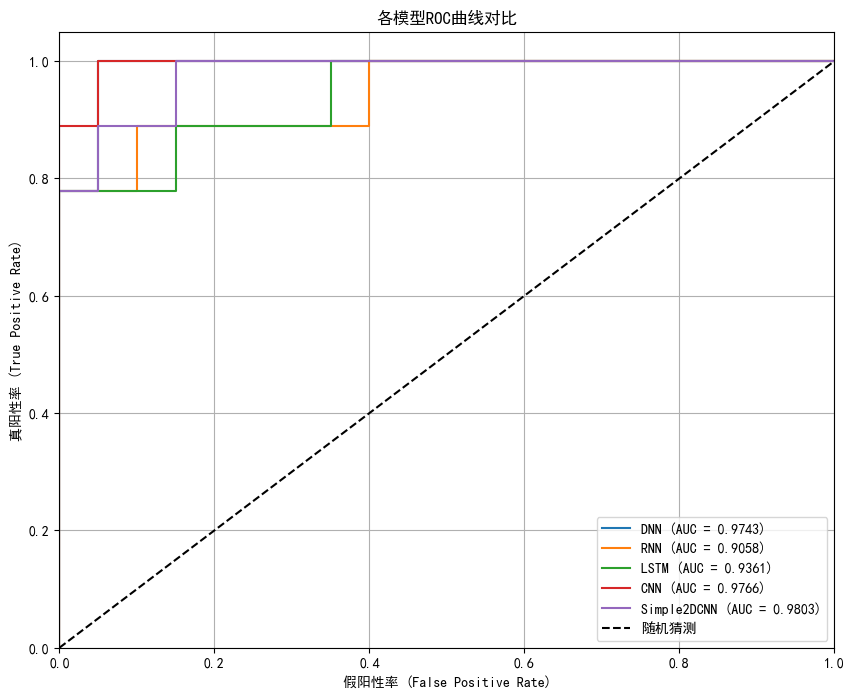

In [306]:
# 绘制ROC曲线
plt.figure(figsize=(10, 8))
for model_name in model_metrics:
    if model_metrics[model_name]['roc_data'] is not None:
        fpr, tpr = model_metrics[model_name]['roc_data']
        auc = np.mean(model_metrics[model_name]['auc_scores'])
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='随机猜测')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (False Positive Rate)')
plt.ylabel('真阳性率 (True Positive Rate)')
plt.title('各模型ROC曲线对比')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### CNN的降维可视化

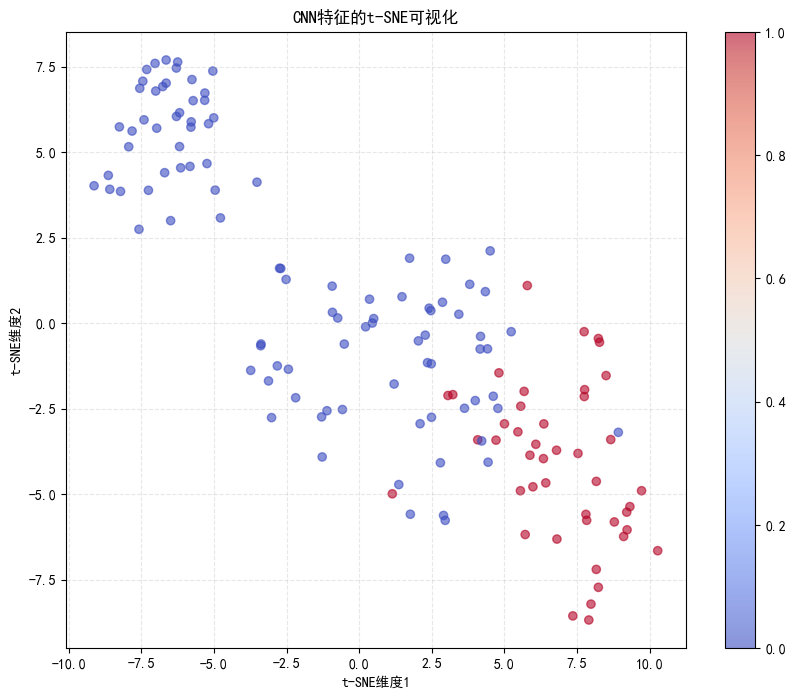

In [323]:
# 修改CNN模型,获取特征
class CNN(nn.Module):
    def __init__(self, input_channels=9):
        super(CNN, self).__init__()
        
        # 根据输入数据特点调整卷积层结构
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(), 
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )
        
        # 根据输入数据维度(44,9)计算展平后的特征维度
        self.flatten_size = 128 * 5  # 44经过3次MaxPool后变为5
        
        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def get_features(self, x):
        # 确保输入维度正确 (batch_size, 44, 9)
        if x.dim() == 2:
            x = x.unsqueeze(0)
            
        # 转换维度用于1D卷积 (batch_size, 9, 44)
        x = x.transpose(1, 2)
        
        # 获取卷积层特征
        x = self.conv1(x)  # (batch_size, 32, 22)
        x = self.conv2(x)  # (batch_size, 64, 11)
        x = self.conv3(x)  # (batch_size, 128, 5)
        
        # 展平
        x = x.view(x.size(0), -1)  # (batch_size, 128*5)
        
        # 获取倒数第二层特征(64维)
        x = self.fc[0](x)  # Linear(640, 64)
        x = self.fc[1](x)  # ReLU
        
        return x
        
    def forward(self, x):
        # 保持原有的前向传播逻辑
        if x.dim() == 2:
            x = x.unsqueeze(0)
        x = x.transpose(1, 2)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x.squeeze()

def visualize_features(model, X, y, device):
    """使用t-SNE可视化模型特征"""
    model.eval()
    X_tensor = torch.FloatTensor(X).to(device)
    
    # 提取特征
    with torch.no_grad():
        features = model.get_features(X_tensor)
        features = features.cpu().numpy()
    
    # t-SNE降维
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)
    
    # 可视化
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], 
                         c=y, cmap='coolwarm', 
                         alpha=0.6)
    plt.colorbar(scatter)
    plt.title('CNN特征的t-SNE可视化')
    plt.xlabel('t-SNE维度1')
    plt.ylabel('t-SNE维度2')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

model = CNN().to(device)
visualize_features(model, X, y, device)

### 预测

#### 导入测试集

In [250]:
#将训练好的模型用于测试集预测，并将结果保存在“测试集”表中的“缺陷检测质量风险 Y”列中。
df_test1 = pd.read_excel(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-12\缺陷检测.xlsx",sheet_name='测试集')
df_test=df_test1
df_test['shift_id']=generate_shift_ids(df_test['缺陷检测质量风险 Y'])
df_test['时间X1'] = pd.to_datetime(df_test['时间X1']).astype(np.int64) // 10**9  # 转换为Unix时间戳

In [251]:
df_test_new = df_test.groupby('shift_id').apply(f)
df_test_new = df_test_new.drop_duplicates()
df_test_new.reset_index(drop=True, inplace=True)

C:\Users\27968\AppData\Local\Temp\ipykernel_70992\3041172377.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



#### 重塑测试集数据

In [215]:
len(df_test_new['shift_id'].unique())

6

In [255]:
X_grouped_test = []
Y_grouped_test = []

for _, group in df_test_new.groupby('shift_id'):
    # 处理X
    group_X_test = scaler.transform(group.drop(columns=['shift_id', '缺陷检测质量风险 Y']).values)
    group_Y_test = group['缺陷检测质量风险 Y'].values
    
    # 将Y值转换为数值型
    group_Y_test = np.where(group_Y_test == '有质量隐患', 1, 0)
    
    # 如果需要padding
    if len(group_X_test) < 44:
        padding_rows = 44 - len(group_X_test)
        # X补0
        X_pad_test = np.pad(group_X_test, ((0, padding_rows), (0, 0)), mode='constant')
        # Y重复最后一个值
        Y_pad_test = np.pad(group_Y_test, (0, padding_rows), mode='edge')
    else:
        X_pad_test = group_X_test[:44]
        Y_pad_test = group_Y_test[:44]
    
    X_grouped_test.append(X_pad_test)
    Y_grouped_test.append(Y_pad_test)

# 合并
X_padded_test = np.vstack(X_grouped_test)
Y_padded_test = np.hstack(Y_grouped_test)
X_padded_tensor_test = torch.FloatTensor(X_padded_test)
Y_padded_tensor_test = torch.FloatTensor(Y_padded_test)
print("With padding:", X_padded_tensor_test.shape, Y_padded_tensor_test.shape)


With padding: torch.Size([264, 9]) torch.Size([264])


In [260]:
n_samples_test = 6
n_timesteps_test = 44  # 每个班次的时间步数
n_features_test = X_padded_tensor_test.shape[-1]  # 特征数量

# 重塑X
X_reshaped_test = X_padded_tensor_test.view(n_samples_test, n_timesteps_test, n_features_test)
print("重塑后的X形状:", X_reshaped_test.shape)

重塑后的X形状: torch.Size([6, 44, 9])


In [300]:
scaler = StandardScaler()
X_test_scaled = []
for i in range(n_samples_test):
   # 提取单个样本 (44, 9)
   sample = X_reshaped_test[i]
   
   # 对该样本的所有特征进行标准化
   sample_scaled = standardize_features(sample)
   
   X_test_scaled.append(sample_scaled)
# 将列表转换为numpy数组
X_test_scaled = np.array(X_test_scaled)
# 转换为tensor
X_test_tensor = torch.FloatTensor(X_test_scaled)
print("测试集数据形状:", X_test_tensor.shape)  # 应该是 (n_samples_test, 44, 9)

测试集数据形状: torch.Size([6, 44, 9])


#### 预测

In [313]:
# 定义模型类型
model_types = ['DNN', 'RNN', 'LSTM', 'CNN', 'Simple2DCNN']
base_dir = r"D:\Python文件\机器学习与数据挖掘课程\saved_models_20241221_101249"  

# 初始化保存预测结果的字典
prediction_results = {}

# 加载每种模型并进行预测
for model_type in model_types:
    model_save_dir = os.path.join(base_dir, model_type)
    
    # 选择第一折模型进行预测
    model_path = os.path.join(model_save_dir, 'fold_1_model.pth')
    
    # 根据模型类型实例化相应的模型
    if model_type == 'DNN':
        model = DNN(input_dim=X_reshaped.shape[2]).to(device)
    elif model_type == 'RNN':
        model = RNN(input_size=X_reshaped.shape[2]).to(device)
    elif model_type == 'LSTM':
        model = LSTM(input_size=X_reshaped.shape[2]).to(device)
    elif model_type == 'CNN':
        model = CNN(input_channels=X_reshaped.shape[2]).to(device)
    elif model_type == 'Simple2DCNN':
        model = Simple2DCNN(input_channels=X_reshaped.shape[2]).to(device)
    else:
        raise ValueError(f"未知的模型类型: {model_type}")
    
    # 加载模型权重
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"已加载模型: {model_type} 从 {model_path}")
    
    # 根据模型类型调整输入张量
    if model_type in ['RNN', 'LSTM']:
        input_tensor = X_test_tensor.view(-1, 44, X_test_tensor.shape[2]).to(device)
    elif model_type == 'CNN':
        input_tensor = X_test_tensor.transpose(1, 2).to(device)
    elif model_type == 'Simple2DCNN':
        input_tensor = X_test_tensor.view(-1, 1, 44, 9).to(device)
    else:
        input_tensor = X_test_tensor.to(device)
    
    # 创建数据加载器
    test_dataset = TensorDataset(input_tensor)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    
    # 存储预测结果
    predictions = []
    probabilities = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch_x = batch[0]
            outputs = model(batch_x)
            probs = outputs.cpu().numpy()
            preds = (outputs > 0.5).float().cpu().numpy()
            probabilities.extend(probs)
            predictions.extend(preds)
    
    # 将预测结果保存到字典中
    prediction_results[model_type] = {
        '预测结果': predictions,
        '概率值': probabilities
    }

# 将所有模型的预测结果整合到一个DataFrame中

# 假设测试集有6个样本，对应6个shift_id
shift_ids = range(1, len(X_test_tensor) + 1)

# 初始化结果DataFrame
results_df = pd.DataFrame({'shift_id': shift_ids})

# 添加每个模型的预测结果和概率值
for model_type in model_types:
    results_df[f'预测结果_{model_type}'] = prediction_results[model_type]['预测结果']
    results_df[f'概率值_{model_type}'] = prediction_results[model_type]['概率值']


已加载模型: DNN 从 D:\Python文件\机器学习与数据挖掘课程\saved_models_20241221_101249\DNN\fold_1_model.pth
已加载模型: RNN 从 D:\Python文件\机器学习与数据挖掘课程\saved_models_20241221_101249\RNN\fold_1_model.pth
已加载模型: LSTM 从 D:\Python文件\机器学习与数据挖掘课程\saved_models_20241221_101249\LSTM\fold_1_model.pth
已加载模型: CNN 从 D:\Python文件\机器学习与数据挖掘课程\saved_models_20241221_101249\CNN\fold_1_model.pth
已加载模型: Simple2DCNN 从 D:\Python文件\机器学习与数据挖掘课程\saved_models_20241221_101249\Simple2DCNN\fold_1_model.pth


C:\Users\27968\AppData\Local\Temp\ipykernel_70992\2081007508.py:30: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



In [325]:
results_df

,shift_id,预测结果_DNN,概率值_DNN,预测结果_RNN,概率值_RNN,预测结果_LSTM,概率值_LSTM,预测结果_CNN,概率值_CNN,预测结果_Simple2DCNN,概率值_Simple2DCNN
0,1,1.0,0.763437,0.0,0.000831,0.0,0.038737,0.0,0.005035,0.0,0.017729
1,2,1.0,0.998574,0.0,0.000605,0.0,0.017630,1.0,0.867656,1.0,0.999399
2,3,1.0,0.968195,0.0,0.001356,0.0,0.045042,0.0,0.035898,0.0,0.044462
3,4,1.0,0.999392,0.0,0.006461,0.0,0.080939,1.0,0.882828,1.0,0.997343
4,5,1.0,0.999631,0.0,0.051698,0.0,0.268280,1.0,0.965486,1.0,0.998697
5,6,1.0,0.784224,0.0,0.002033,0.0,0.056299,0.0,0.008203,0.0,0.014492


#### 保存

In [315]:
results_df.to_excel(r"D:\Python文件\机器学习与数据挖掘课程\缺陷检测预测结果.xlsx", sheet_name='测试集_预测结果', index=False)